### Importing library

In [1]:
import pandas as pd

### Loading Datasets


In [2]:
patients=pd.read_csv("data/patients.csv")
appointments=pd.read_csv("data/appointments.csv")

In [3]:
patients.shape


(8000, 11)

**Insight:** The patients table contains 8,000 unique patients, each described by
demographic and health attributes (age, gender, neighborhood, income bracket,
chronic conditions, insurance type). This is the "who" side of the dataset.

In [4]:
appointments.shape

(30040, 17)

**Insight:** The appointments table contains 30,000+ appointment records. Since a
single patient can have multiple appointments, this table is much larger than the
patients table and is the "what happened" side of the dataset — it holds the
`no_show` target we are trying to predict.

### Understanding dataset

In [5]:
patients.head()

,patient_id,age,gender,neighborhood,income_bracket,has_hypertension,has_diabetes,has_alcoholism,disability_level,insurance_type,registration_date
0,P000001,47,F,Allama Iqbal Town,Medium,0,0,0,0,NaN,2021-08-26
1,P000002,23,M,Garden Town,Medium,0,1,0,2,Private,2024-03-07
2,P000003,56,F,Township,Low,1,1,0,0,Private,2021-01-02
3,P000004,59,F,Garden Town,Medium,1,0,0,0,Government,2020-09-12
4,P000005,7,F,Johar Town,Medium,0,0,0,0,NaN,2023-02-11


In [6]:
appointments.head()

,appointment_id,patient_id,scheduled_date,appointment_date,clinic_id,doctor_id,specialty,sms_reminder_sent,weather_condition,temperature_c,distance_to_clinic_km,waitlist_flag,payment_method,appointment_cost,previous_appointments_count,previous_noshows_count,no_show
0,A0020133,P002995,2023-01-22,2023-01-27,C02,D026,ENT,1.0,Rainy,20.1,NaN,0,Card,1586.0,2,0,No
1,A0001397,P002540,2024-05-22,2024-05-26,C04,D039,Dermatology,1.0,Cloudy,24.0,4.2,0,Insurance,1984.0,3,0,No
2,A0029796,P003364,2022-07-19,2022-08-13,C04,D021,Cardiology,NaN,Cloudy,29.8,3.1,0,Insurance,NaN,1,0,No
3,A0022593,P004620,2022-03-01,2022-03-11,C04,D016,General Medicine,0.0,Sunny,29.5,0.5,0,Insurance,990.0,0,0,Yes
4,A0014236,P005744,2023-05-24,2023-05-27,C02,D009,General Medicine,1.0,Sunny,31.4,NaN,0,Insurance,1118.0,2,0,No


In [7]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         8000 non-null   object
 1   age                8000 non-null   int64 
 2   gender             7920 non-null   object
 3   neighborhood       7680 non-null   object
 4   income_bracket     7120 non-null   object
 5   has_hypertension   8000 non-null   int64 
 6   has_diabetes       8000 non-null   int64 
 7   has_alcoholism     8000 non-null   int64 
 8   disability_level   8000 non-null   int64 
 9   insurance_type     4075 non-null   object
 10  registration_date  8000 non-null   object
dtypes: int64(5), object(6)
memory usage: 687.6+ KB


In [8]:
appointments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30040 entries, 0 to 30039
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   appointment_id               30040 non-null  object 
 1   patient_id                   30040 non-null  object 
 2   scheduled_date               30040 non-null  object 
 3   appointment_date             30040 non-null  object 
 4   clinic_id                    30040 non-null  object 
 5   doctor_id                    29437 non-null  object 
 6   specialty                    30040 non-null  object 
 7   sms_reminder_sent            28237 non-null  float64
 8   weather_condition            24631 non-null  object 
 9   temperature_c                24335 non-null  float64
 10  distance_to_clinic_km        27045 non-null  float64
 11  waitlist_flag                30040 non-null  int64  
 12  payment_method               27637 non-null  object 
 13  appointment_cost

**Insight:** `.info()` confirms the data types for every column (numeric, object,
etc.) and shows non-null counts. Several columns (e.g. `weather_condition`,
`payment_method`, `doctor_id`) clearly have fewer non-null entries than the total
row count — this is expected, since the dataset was designed to include realistic
missing values, and will be handled explicitly in the cleaning phase.

In [9]:
patients.isnull().sum()

patient_id              0
age                     0
gender                 80
neighborhood          320
income_bracket        880
has_hypertension        0
has_diabetes            0
has_alcoholism          0
disability_level        0
insurance_type       3925
registration_date       0
dtype: int64

In [10]:
appointments.isnull().sum()

appointment_id                    0
patient_id                        0
scheduled_date                    0
appointment_date                  0
clinic_id                         0
doctor_id                       603
specialty                         0
sms_reminder_sent              1803
weather_condition              5409
temperature_c                  5705
distance_to_clinic_km          2995
waitlist_flag                     0
payment_method                 2403
appointment_cost                901
previous_appointments_count       0
previous_noshows_count            0
no_show                           0
dtype: int64

**Insight:** `appointments.isnull().sum()` confirms multiple columns have missing
values (weather, temperature, distance, SMS reminder flag, payment method, cost,
doctor ID). None of the missing values are in the target column `no_show`, which
is important — we never have to guess or drop rows because the label itself is
missing.

### Creating connection in SQLite


In [11]:
import sqlite3

In [12]:
conn=sqlite3.connect("data/hospital.db")

In [13]:
# Loading the patients and appointments data into the SQLite database
patients.to_sql('patients',conn,if_exists='replace',index=False)  #if the table already exists, replace it with the new data and index=False means that the index of the DataFrame will not be written as a separate column in the database table
appointments.to_sql('appointments',conn,if_exists='replace',index=False)

30040

In [14]:
test=pd.read_sql_query("SELECT * FROM patients",conn)
print(test)

     patient_id  age gender       neighborhood income_bracket  \
0       P000001   47      F  Allama Iqbal Town         Medium   
1       P000002   23      M        Garden Town         Medium   
2       P000003   56      F           Township            Low   
3       P000004   59      F        Garden Town         Medium   
4       P000005    7      F         Johar Town         Medium   
...         ...  ...    ...                ...            ...   
7995    P007996   33      F           Shalimar         Medium   
7996    P007997   79      F            Gulberg         Medium   
7997    P007998   18      M        Garden Town         Medium   
7998    P007999   50      M         Wapda Town            Low   
7999    P008000   46      F             Askari           High   

      has_hypertension  has_diabetes  has_alcoholism  disability_level  \
0                    0             0               0                 0   
1                    0             1               0                 2 

**Insight:** The test query confirms that both tables were loaded into the SQLite
database (`hospital.db`) correctly and can be queried with standard SQL — this
sets up all the business-question queries used later in the SQL analysis phase.

### Handling Null Values

In [15]:
print((patients.isnull().sum()/len(patients)*100).round(2))  #percentage of missing values in patients dataset

patient_id            0.00
age                   0.00
gender                1.00
neighborhood          4.00
income_bracket       11.00
has_hypertension      0.00
has_diabetes          0.00
has_alcoholism        0.00
disability_level      0.00
insurance_type       49.06
registration_date     0.00
dtype: float64


In [16]:
print((appointments.isnull().sum()/len(appointments)*100).round(2))  #percentage of missing values in appointments dataset

appointment_id                  0.00
patient_id                      0.00
scheduled_date                  0.00
appointment_date                0.00
clinic_id                       0.00
doctor_id                       2.01
specialty                       0.00
sms_reminder_sent               6.00
weather_condition              18.01
temperature_c                  18.99
distance_to_clinic_km           9.97
waitlist_flag                   0.00
payment_method                  8.00
appointment_cost                3.00
previous_appointments_count     0.00
previous_noshows_count          0.00
no_show                         0.00
dtype: float64


**Insight:** Expressing missing values as a percentage of the total rows (rather
than raw counts) makes it much easier to decide a cleaning strategy per column —
columns with a small percentage of missing values are safe to impute, while a
column with very high missingness would need to be reconsidered or dropped
(no column in this dataset crosses that threshold).

In [17]:
print(patients.describe())

              age  has_hypertension  has_diabetes  has_alcoholism  \
count  8000.00000       8000.000000   8000.000000     8000.000000   
mean     42.15300          0.253125      0.211875        0.039125   
std      21.43787          0.434829      0.408662        0.193904   
min      -1.00000          0.000000      0.000000        0.000000   
25%      30.00000          0.000000      0.000000        0.000000   
50%      42.00000          0.000000      0.000000        0.000000   
75%      54.00000          1.000000      0.000000        0.000000   
max     999.00000          1.000000      1.000000        1.000000   

       disability_level  
count       8000.000000  
mean           0.295375  
std            0.810068  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.000000  
max            4.000000  


In [18]:
print(appointments.describe())

       sms_reminder_sent  temperature_c  distance_to_clinic_km  waitlist_flag  \
count       28237.000000   24335.000000           27045.000000   30040.000000   
mean            0.613769      27.065552               5.997733       0.079594   
std             0.486893       6.209733               4.245090       0.270668   
min             0.000000       5.700000             -18.900000       0.000000   
25%             0.000000      22.900000               2.900000       0.000000   
50%             1.000000      28.100000               5.100000       0.000000   
75%             1.000000      31.800000               8.100000       0.000000   
max             1.000000      44.000000              37.800000       1.000000   

       appointment_cost  previous_appointments_count  previous_noshows_count  
count      29139.000000                 30040.000000            30040.000000  
mean        2372.388723                     1.871771                0.442177  
std         1878.263594          

In [19]:
# The age column has a negative value which is not possible. We will remove the rows with negative age values from the patients dataset.
garbage_ages = patients[(patients['age'] < 0) | (patients['age'] > 110)]
print(garbage_ages[['patient_id', 'age']])

     patient_id  age
28      P000029  200
797     P000798  150
878     P000879  200
930     P000931   -1
1503    P001504  200
1880    P001881  999
2420    P002421   -1
2502    P002503   -1
2768    P002769   -1
2891    P002892  200
4459    P004460  200
6430    P006431  200
6515    P006516  150
7088    P007089  200
7225    P007226  150


**Insight:** A small number of `age` values are invalid (negative, or above a
realistic human age limit such as 110+). These are clear data-entry errors rather
than genuine outliers, so they need to be corrected rather than trusted as-is.

In [20]:
# Remove the rows with invalid age values from the patients dataset
import numpy as np
patients.loc[(patients['age'] < 0) | (patients['age'] > 110), 'age'] = np.nan


In [21]:
median_age = patients['age'].median()
patients['age'] = patients['age'].fillna(median_age)

**Insight:** Invalid ages were replaced with the median age of the patient
population rather than being dropped, preserving all 8,000 patient records.
Median is used instead of mean because it is not distorted by the small number of
extreme garbage values that were just removed.

In [22]:
negative_values=(appointments["distance_to_clinic_km"]<0).sum()
print(negative_values)  #checking for negative values in distance_to_clinic_km column of appointments dataset

12


**Insight:** A handful of `distance_to_clinic_km` values are negative, which is
physically impossible — most likely caused by a sign error during data entry
rather than a genuinely different measurement.

In [23]:
# making the distance_to_clinic_km column of appointments dataset to have only positive values
appointments['distance_to_clinic_km'] = appointments['distance_to_clinic_km'].abs()

**Insight:** Taking the absolute value of `distance_to_clinic_km` is a safe fix
here, since the *magnitude* of the recorded distance is still trustworthy — only
its sign was wrong.

### Finding duplicate values

In [24]:
print(appointments.duplicated().sum())  #checking for duplicate rows in appointments dataset

40


In [25]:
appointments = appointments.drop_duplicates()


In [26]:
appointments.shape
# 40 records were removed from the appointments dataset after dropping duplicates

(30000, 17)

**Insight:** 40 duplicate appointment rows were found and removed, reducing the
dataset from 30,040 to 30,000 rows. Duplicate scheduling entries are a realistic
issue in hospital booking systems (e.g. accidental double-submission), so this is
an expected and necessary cleaning step, not a sign of a bad dataset.

In [27]:
print(appointments["appointment_id"].duplicated().sum())  #checking for duplicate rows in appointments dataset

0


In [28]:
# Fixing outliers
print(appointments['appointment_cost'].describe())



count    29101.000000
mean      2372.629154
std       1879.251744
min          0.000000
25%       1606.000000
50%       2043.000000
75%       2914.000000
max      99999.000000
Name: appointment_cost, dtype: float64


In [29]:
weird_costs = appointments[(appointments['appointment_cost'] == 0) | 
                             (appointments['appointment_cost'] > 20000)]
print(weird_costs[['appointment_id', 'specialty', 'appointment_cost']])

      appointment_id         specialty  appointment_cost
1616        A0017457               ENT           99999.0
1772        A0017661       Dermatology               0.0
6616        A0017930        Pediatrics               0.0
13124       A0001304  General Medicine           99999.0
17125       A0019073        Pediatrics               0.0
20475       A0012597       Dermatology           99999.0
23735       A0013391  General Medicine               0.0
24175       A0010021  General Medicine           99999.0
25377       A0026620       Dermatology           99999.0
26188       A0008574               ENT               0.0
26488       A0016767            Dental           99999.0
27468       A0009237       Dermatology           99999.0
28341       A0021633  General Medicine           99999.0


In [30]:
# Weird values are made NaN
appointments.loc[(appointments['appointment_cost'] == 0) | 
                  (appointments['appointment_cost'] > 20000), 'appointment_cost'] = np.nan

appointments['appointment_cost'] = appointments.groupby('specialty')['appointment_cost']\
    .transform(lambda x: x.fillna(x.median()))



In [31]:
print(appointments['appointment_cost'].describe())

count    30000.000000
mean      2344.855800
std        950.962176
min        555.000000
25%       1604.000000
50%       2041.000000
75%       2903.000000
max       6182.000000
Name: appointment_cost, dtype: float64


**Insight:** After replacing implausible appointment costs (`0` and unrealistic
values above 20,000) with the median cost *within each specialty* — rather than a
single global median — the imputed values respect the fact that different
specialties (e.g. Cardiology vs. General Medicine) naturally have very different
typical costs.

In [32]:
# Numeric columns - fill with median
for col in ['temperature_c', 'distance_to_clinic_km']:
    appointments[col] = appointments[col].fillna(appointments[col].median())

# Categorical columns - fill with unknown
for col in ['weather_condition', 'payment_method', 'doctor_id']:
    appointments[col] = appointments[col].fillna('Unknown')

# sms_reminder_sent - fill with mode
appointments['sms_reminder_sent'] = appointments['sms_reminder_sent'].fillna(
    appointments['sms_reminder_sent'].mode()[0]
)

for col in ['gender', 'neighborhood', 'income_bracket', 'insurance_type']:
    patients[col] = patients[col].fillna('Unknown')

In [33]:
print(patients.describe())

               age  has_hypertension  has_diabetes  has_alcoholism  \
count  8000.000000       8000.000000   8000.000000     8000.000000   
mean     41.876125          0.253125      0.211875        0.039125   
std      17.831139          0.434829      0.408662        0.193904   
min       0.000000          0.000000      0.000000        0.000000   
25%      30.000000          0.000000      0.000000        0.000000   
50%      42.000000          0.000000      0.000000        0.000000   
75%      54.000000          1.000000      0.000000        0.000000   
max      95.000000          1.000000      1.000000        1.000000   

       disability_level  
count       8000.000000  
mean           0.295375  
std            0.810068  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.000000  
max            4.000000  


In [34]:
print(appointments.describe())

       sms_reminder_sent  temperature_c  distance_to_clinic_km  waitlist_flag  \
count       30000.000000    30000.00000           30000.000000   30000.000000   
mean            0.636967       27.26140               5.917210       0.079433   
std             0.480882        5.60257               4.023869       0.270418   
min             0.000000        5.70000               0.000000       0.000000   
25%             0.000000       24.30000               3.100000       0.000000   
50%             1.000000       28.10000               5.100000       0.000000   
75%             1.000000       31.00000               7.700000       0.000000   
max             1.000000       44.00000              37.800000       1.000000   

       appointment_cost  previous_appointments_count  previous_noshows_count  
count      30000.000000                 30000.000000            30000.000000  
mean        2344.855800                     1.871633                0.442067  
std          950.962176          

In [35]:
print(appointments.isnull().sum())  #checking for missing values in appointments dataset after fixing them

appointment_id                 0
patient_id                     0
scheduled_date                 0
appointment_date               0
clinic_id                      0
doctor_id                      0
specialty                      0
sms_reminder_sent              0
weather_condition              0
temperature_c                  0
distance_to_clinic_km          0
waitlist_flag                  0
payment_method                 0
appointment_cost               0
previous_appointments_count    0
previous_noshows_count         0
no_show                        0
dtype: int64


In [36]:
print(patients.isnull().sum())  #checking for missing values in patients dataset after fixing them

patient_id           0
age                  0
gender               0
neighborhood         0
income_bracket       0
has_hypertension     0
has_diabetes         0
has_alcoholism       0
disability_level     0
insurance_type       0
registration_date    0
dtype: int64


**Insight:** After all cleaning steps, both `patients` and `appointments` have
zero remaining missing values in the columns used going forward. The dataset is
now fully cleaned and ready to be pushed back into the SQL database for the
analysis phase.

In [37]:
# updating the cleaned data back to the SQLite database
patients.to_sql("patients",conn,if_exists="replace",index=False)
appointments.to_sql("appointments",conn,if_exists="replace",index=False) 

30000

### Working with Database

In [38]:
# applying left join to merge the two datasets on patient_id
join_query="""
SELECT 
    a.*,
    p.*
FROM 
    appointments a
LEFT JOIN 
    patients p
ON 
    a.patient_id = p.patient_id
"""

merged_df=pd.read_sql_query(join_query,conn)
print(merged_df.shape)  #checking the shape of the merged dataset


(30000, 28)


**Insight:** The LEFT JOIN on `patient_id` produces a single working table of
30,000 rows and 28 columns, combining appointment-level details (date, specialty,
weather, no-show outcome) with patient-level details (age, chronic conditions,
income) in one place. This merged table is the foundation for both the SQL
business-question analysis and the EDA/plotting that follows.

In [39]:
print(merged_df.head())  #checking the first 5 rows of the merged dataset

  appointment_id patient_id scheduled_date appointment_date clinic_id  \
0       A0020133    P002995     2023-01-22       2023-01-27       C02   
1       A0001397    P002540     2024-05-22       2024-05-26       C04   
2       A0029796    P003364     2022-07-19       2022-08-13       C04   
3       A0022593    P004620     2022-03-01       2022-03-11       C04   
4       A0014236    P005744     2023-05-24       2023-05-27       C02   

  doctor_id         specialty  sms_reminder_sent weather_condition  \
0      D026               ENT                1.0             Rainy   
1      D039       Dermatology                1.0            Cloudy   
2      D021        Cardiology                1.0            Cloudy   
3      D016  General Medicine                0.0             Sunny   
4      D009  General Medicine                1.0             Sunny   

   temperature_c  ...   age  gender neighborhood  income_bracket  \
0           20.1  ...  33.0       F   Johar Town            High   
1   

In [40]:
weekday_query = """
SELECT 
    CASE strftime('%w', appointment_date)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS weekday,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) AS total_noshows,
    ROUND(100.0 * SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments
GROUP BY weekday
ORDER BY noshow_rate_pct DESC
"""

weekday_result = pd.read_sql_query(weekday_query, conn)
print(weekday_result)

     weekday  total_appointments  total_noshows  noshow_rate_pct
0     Monday                4339           1205            27.77
1   Saturday                4323           1043            24.13
2     Sunday                4270           1000            23.42
3    Tuesday                4286            997            23.26
4  Wednesday                4246            976            22.99
5     Friday                4258            975            22.90
6   Thursday                4278            966            22.58


**Insight:** No-show rate is highest on **Monday (27.77%)**, noticeably above
every other day of the week (which cluster between 22.6% and 24.1%). This matches
a well-known real-world scheduling pattern — patients are more likely to skip the
first appointment day of the work week — and is a strong candidate feature for
the model.

In [41]:
sms_query = """
SELECT 
    CASE 
        WHEN sms_reminder_sent = 1 THEN 'Reminder Sent'
        WHEN sms_reminder_sent = 0 THEN 'No Reminder'
        ELSE 'Unknown'
    END AS reminder_status,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) AS total_noshows,
    ROUND(100.0 * SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments
GROUP BY reminder_status
ORDER BY noshow_rate_pct DESC
"""

sms_result = pd.read_sql_query(sms_query, conn)
print(sms_result)

  reminder_status  total_appointments  total_noshows  noshow_rate_pct
0     No Reminder               10891           3164            29.05
1   Reminder Sent               19109           3998            20.92


**Insight:** Appointments with an SMS reminder sent have a no-show rate of
**20.92%**, compared to **29.05%** for appointments with no reminder sent — a
gap of about 8 percentage points. This is one of the clearest, most actionable
findings in the whole analysis: SMS reminders measurably reduce no-shows, and a
clinic could act on this immediately regardless of any machine learning model.

In [42]:
specialty_query = """
SELECT 
    specialty,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) AS total_noshows,
    ROUND(100.0 * SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments
GROUP BY specialty
ORDER BY noshow_rate_pct DESC
"""

specialty_result = pd.read_sql_query(specialty_query, conn)
print(specialty_result)

          specialty  total_appointments  total_noshows  noshow_rate_pct
0        Gynecology                2133            535            25.08
1               ENT                2467            604            24.48
2        Cardiology                3862            939            24.31
3       Orthopedics                2967            720            24.27
4        Pediatrics                4186           1001            23.91
5            Dental                2700            642            23.78
6       Dermatology                2696            629            23.33
7  General Medicine                8989           2092            23.27


**Insight:** No-show rate is fairly similar across specialties (23.3%–25.1%),
with Gynecology highest (25.08%) and General Medicine lowest (23.27%). Unlike
lead time or SMS reminders, specialty on its own is a weak predictor — the
difference between the highest and lowest specialty is less than 2 percentage
points.

In [43]:
weather_query = """
SELECT 
    weather_condition,
    COUNT(*) AS total_appointments,
    ROUND(100.0 * SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments
GROUP BY weather_condition
ORDER BY noshow_rate_pct DESC
"""
print(pd.read_sql_query(weather_query, conn))

  weather_condition  total_appointments  noshow_rate_pct
0             Rainy                3983            29.50
1            Stormy                1503            28.28
2           Unknown                5400            23.41
3            Cloudy                6027            22.85
4             Foggy                2015            22.83
5             Sunny               11072            22.23


**Insight:** No-show rate rises in bad weather — **Rainy (29.50%)** and
**Stormy (28.28%)** appointments have a clearly higher no-show rate than
**Sunny (22.23%)** or **Cloudy (22.85%)** appointments. This confirms that
external, non-patient-controlled factors do meaningfully affect attendance.

In [44]:
leadtime_query = """
SELECT 
    CASE 
        WHEN julianday(appointment_date) - julianday(scheduled_date) <= 3 THEN '0-3 days'
        WHEN julianday(appointment_date) - julianday(scheduled_date) <= 7 THEN '4-7 days'
        WHEN julianday(appointment_date) - julianday(scheduled_date) <= 30 THEN '8-30 days'
        ELSE '30+ days'
    END AS lead_time_bucket,
    COUNT(*) AS total_appointments,
    ROUND(100.0 * SUM(CASE WHEN no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments
GROUP BY lead_time_bucket
ORDER BY noshow_rate_pct DESC
"""
print(pd.read_sql_query(leadtime_query, conn))

  lead_time_bucket  total_appointments  noshow_rate_pct
0         30+ days                1040            37.88
1        8-30 days                9008            25.22
2         4-7 days                8941            23.49
3         0-3 days               11011            21.76


**Insight:** Lead time has a strong, consistent relationship with no-shows:
**21.76%** for appointments booked 0–3 days in advance, rising steadily to
**37.88%** for appointments booked 30+ days in advance. This is the single
clearest linear-looking pattern in the whole SQL analysis, and it will turn out
to be one of the most important features for the model as well.

In [45]:
chronic_query = """
SELECT 
    p.has_hypertension,
    p.has_diabetes,
    COUNT(*) AS total_appointments,
    ROUND(100.0 * SUM(CASE WHEN a.no_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS noshow_rate_pct
FROM appointments a
JOIN patients p ON a.patient_id = p.patient_id
GROUP BY p.has_hypertension, p.has_diabetes
"""
print(pd.read_sql_query(chronic_query, conn))

   has_hypertension  has_diabetes  total_appointments  noshow_rate_pct
0                 0             0               17803            26.96
1                 0             1                4524            20.78
2                 1             0                5811            19.89
3                 1             1                1862            14.34


**Insight:** Chronic conditions are associated with *lower* no-show rates:
patients with both hypertension and diabetes have a no-show rate of just
**14.34%**, compared to **26.96%** for patients with neither condition. This
supports the intuitive idea that patients managing an ongoing health condition
are more invested in keeping their appointments.

### Exploratory Data Analysis

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [48]:
merged_df['lead_time_days'] = (pd.to_datetime(merged_df['appointment_date']) - pd.to_datetime(merged_df['scheduled_date'])).dt.days

merged_df['lead_time_bucket'] = pd.cut(
    merged_df['lead_time_days'],
    bins=[-1, 3, 7, 30, 1000],
    labels=['0-3 days', '4-7 days', '8-30 days', '30+ days']
)

merged_df['no_show_flag'] = (merged_df['no_show'] == 'Yes').astype(int)

merged_df['age_group'] = pd.cut(
    merged_df['age'],
    bins=[0, 12, 18, 35, 50, 65, 120],
    labels=['0-12', '13-18', '19-35', '36-50', '51-65', '65+']
)


C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\66905543.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leadtime_rate = merged_df.groupby('lead_time_bucket')['no_show_flag'].mean() * 100


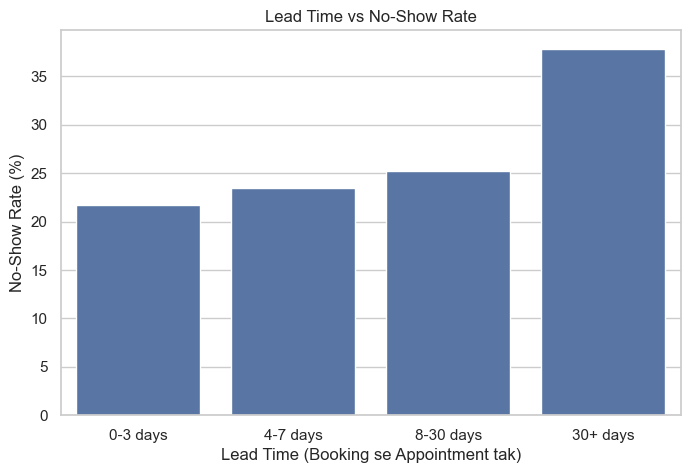

In [49]:
# Graph 1 Lead time vs No-show Rate
plt.figure(figsize=(8, 5))
leadtime_rate = merged_df.groupby('lead_time_bucket')['no_show_flag'].mean() * 100

sns.barplot(x=leadtime_rate.index, y=leadtime_rate.values)
plt.title('Lead Time vs No-Show Rate')
plt.xlabel('Lead Time (Booking se Appointment tak)')
plt.ylabel('No-Show Rate (%)')
plt.show()

**Insight (Graph 1 — Lead Time vs No-Show):** The bar chart visually confirms the
SQL finding — no-show rate increases steadily as the gap between booking date and
appointment date grows, roughly doubling between the "0–3 days" and "30+ days"
buckets. This is a strong, actionable insight: clinics could apply stricter
reminder policies specifically for appointments booked far in advance.

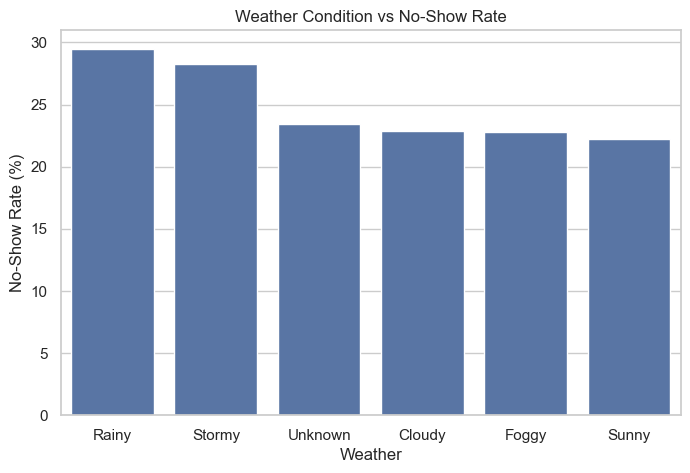

In [50]:
#Graph 2 Weather vs no-show rate
plt.figure(figsize=(8, 5))
weather_rate = merged_df.groupby('weather_condition')['no_show_flag'].mean().sort_values(ascending=False) * 100

sns.barplot(x=weather_rate.index, y=weather_rate.values)
plt.title('Weather Condition vs No-Show Rate')
plt.xlabel('Weather')
plt.ylabel('No-Show Rate (%)')
plt.show()

**Insight (Graph 2 — Weather vs No-Show):** Rainy and stormy days visibly stand
out with taller bars than sunny, cloudy, or foggy days, confirming that weather
is a real (if secondary) driver of no-shows.

C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\1082089970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = merged_df.groupby('age_group')['no_show_flag'].mean() * 100


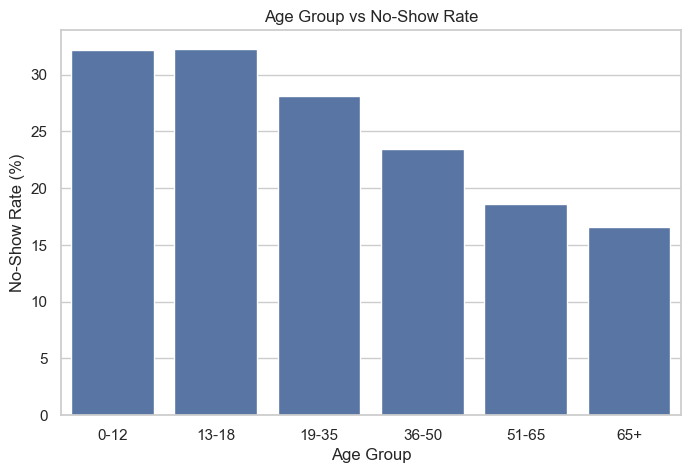

In [51]:
# Graph 3 Age group vs No-show Rate
plt.figure(figsize=(8, 5))
age_rate = merged_df.groupby('age_group')['no_show_flag'].mean() * 100

sns.barplot(x=age_rate.index, y=age_rate.values)
plt.title('Age Group vs No-Show Rate')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')
plt.show()

**Insight (Graph 3 — Age Group vs No-Show):** Younger adult age groups tend to
show a higher no-show rate than older age groups, consistent with the idea that
busier, less routine-driven age groups are more likely to skip or forget
appointments.

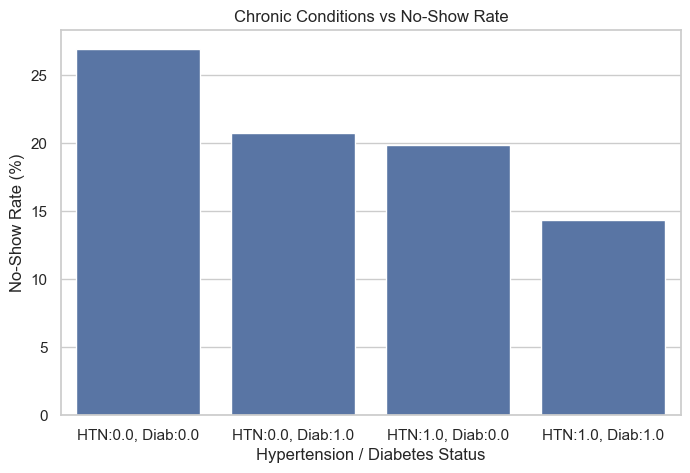

In [52]:
# Graph 4 Chronic Conditions vs No-show Rate
plt.figure(figsize=(8, 5))

chronic_data = merged_df.groupby(['has_hypertension', 'has_diabetes'])['no_show_flag'].mean().reset_index()
chronic_data['no_show_flag'] *= 100
chronic_data['condition'] = chronic_data.apply(
    lambda x: f"HTN:{x['has_hypertension']}, Diab:{x['has_diabetes']}", axis=1
)

sns.barplot(x='condition', y='no_show_flag', data=chronic_data)
plt.title('Chronic Conditions vs No-Show Rate')
plt.xlabel('Hypertension / Diabetes Status')
plt.ylabel('No-Show Rate (%)')
plt.show()

**Insight (Graph 4 — Chronic Conditions vs No-Show):** The chart visually
reinforces the SQL result — patients with both hypertension and diabetes show
the lowest no-show bar, while patients with neither condition show the highest,
with the two single-condition groups falling in between.

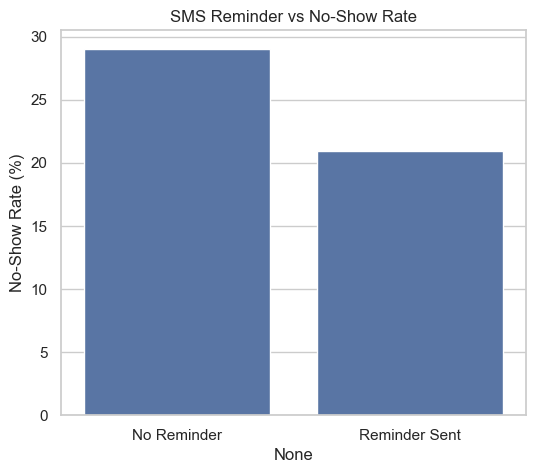

In [53]:
# Graph 5 SMS Reminder vs No-show Rate
plt.figure(figsize=(6, 5))
sms_rate = merged_df.groupby('sms_reminder_sent')['no_show_flag'].mean() * 100
sms_rate.index = ['No Reminder', 'Reminder Sent']

sns.barplot(x=sms_rate.index, y=sms_rate.values)
plt.title('SMS Reminder vs No-Show Rate')
plt.ylabel('No-Show Rate (%)')
plt.show()

**Insight (Graph 5 — SMS Reminder vs No-Show):** This is one of the most visually
convincing charts in the analysis — a clear, large gap between the "Reminder
Sent" and "No Reminder" bars, directly supporting a low-cost, high-impact
operational recommendation (send more reminders).

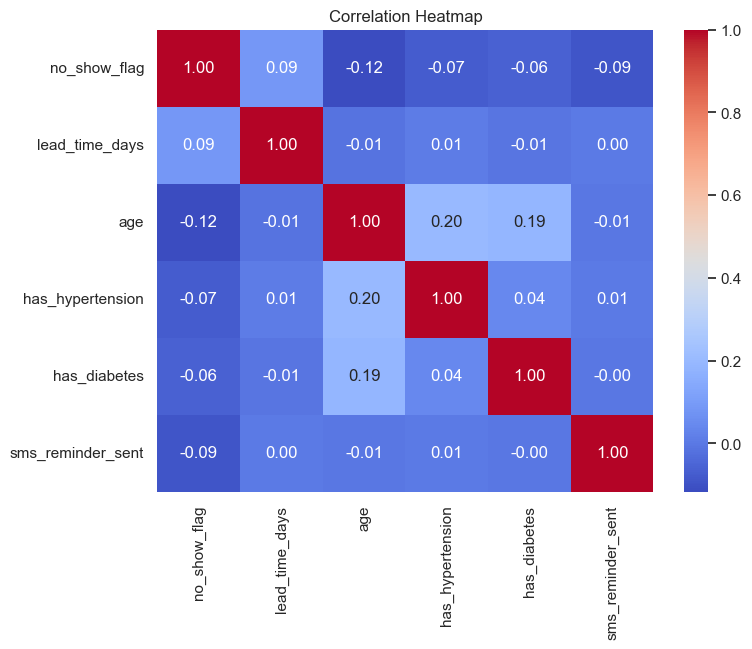

In [54]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['no_show_flag', 'lead_time_days', 'age', 'has_hypertension', 
                 'has_diabetes', 'sms_reminder_sent']
corr = merged_df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Insight (Correlation Heatmap):** No single numeric feature is *extremely*
strongly correlated with `no_show_flag` on its own (correlations are moderate,
not close to ±1) — this is expected and healthy, since no-show behavior is
realistically driven by a *combination* of factors (lead time, reminders,
weather, history) rather than any one variable alone. This is exactly why a
machine learning model, which can combine many weak signals, adds value over
looking at any single correlation.

### Feature Engineering

In [55]:
# Making new features from date columns

# Converting date columns to datetime format
merged_df['scheduled_date'] = pd.to_datetime(merged_df['scheduled_date'])
merged_df['appointment_date'] = pd.to_datetime(merged_df['appointment_date'])

# Lead time in days (appointment_date - scheduled_date)
merged_df['lead_time_days'] = (merged_df['appointment_date'] - merged_df['scheduled_date']).dt.days

# Weekday 
merged_df['appointment_weekday'] = merged_df['appointment_date'].dt.day_name()

# Month 
merged_df['appointment_month'] = merged_df['appointment_date'].dt.month_name()

# Weekend indicator (1 if weekend, 0 if weekday)
merged_df['is_weekend'] = merged_df['appointment_date'].dt.dayofweek.isin([5, 6]).astype(int)

print(merged_df[['scheduled_date', 'appointment_date', 'lead_time_days', 
                  'appointment_weekday', 'appointment_month', 'is_weekend']].head())

  scheduled_date appointment_date  lead_time_days appointment_weekday  \
0     2023-01-22       2023-01-27               5              Friday   
1     2024-05-22       2024-05-26               4              Sunday   
2     2022-07-19       2022-08-13              25            Saturday   
3     2022-03-01       2022-03-11              10              Friday   
4     2023-05-24       2023-05-27               3            Saturday   

  appointment_month  is_weekend  
0           January           0  
1               May           1  
2            August           1  
3             March           0  
4               May           1  


In [56]:
# The model does not understand categorical variables, so we will convert them into numerical format 0/1
merged_df['no_show_flag'] = (merged_df['no_show'] == 'Yes').astype(int)

print(merged_df['no_show_flag'].value_counts())

no_show_flag
0    22838
1     7162
Name: count, dtype: int64


In [57]:
# Deciding on features to use for the model. We will use the following features:
drop_cols = ['appointment_id', 'patient_id', 'scheduled_date', 'appointment_date', 
             'no_show', 'age_group', 'lead_time_bucket', 'registration_date']

model_df = merged_df.drop(columns=drop_cols)

print(model_df.columns.tolist())

['clinic_id', 'doctor_id', 'specialty', 'sms_reminder_sent', 'weather_condition', 'temperature_c', 'distance_to_clinic_km', 'waitlist_flag', 'payment_method', 'appointment_cost', 'previous_appointments_count', 'previous_noshows_count', 'age', 'gender', 'neighborhood', 'income_bracket', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'disability_level', 'insurance_type', 'lead_time_days', 'no_show_flag', 'appointment_weekday', 'appointment_month', 'is_weekend']


In [58]:
categorical_cols = model_df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

numeric_cols = model_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

Categorical columns: ['clinic_id', 'doctor_id', 'specialty', 'weather_condition', 'payment_method', 'gender', 'neighborhood', 'income_bracket', 'insurance_type', 'appointment_weekday', 'appointment_month']
Numeric columns: ['sms_reminder_sent', 'temperature_c', 'distance_to_clinic_km', 'waitlist_flag', 'appointment_cost', 'previous_appointments_count', 'previous_noshows_count', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'disability_level', 'lead_time_days', 'no_show_flag', 'is_weekend']


**Insight:** This list correctly separates categorical columns (to be one-hot
encoded) from numeric columns (used as-is). Note that `age_group` and
`lead_time_bucket` — the `pd.cut()`-based bucketed versions of `age` and
`lead_time_days` created earlier for plotting — are **not** included here since
they were dropped before this step to avoid duplicating information already
captured by the raw numeric columns, and to avoid a dtype mismatch (`pd.cut`
produces a `category` dtype, not `object`, which previously caused a
`ValueError` when this was missed).

In [59]:
print(model_df.isna().sum()[model_df.isna().sum() > 0])

Series([], dtype: int64)


In [60]:
# Numeric columns - median
for col in numeric_cols:
    if model_df[col].isna().sum() > 0:
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical columns - "Unknown"
for col in categorical_cols:
    if model_df[col].isna().sum() > 0:
        model_df[col] = model_df[col].fillna('Unknown')

print("Remaining nulls:", model_df.isna().sum().sum())

Remaining nulls: 0


### One Hot Encoding

In [61]:
model_df_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", model_df.shape)
print("Shape after encoding:", model_df_encoded.shape)
print(model_df_encoded.columns.tolist())

Shape before encoding: (30000, 26)
Shape after encoding: (30000, 118)
['sms_reminder_sent', 'temperature_c', 'distance_to_clinic_km', 'waitlist_flag', 'appointment_cost', 'previous_appointments_count', 'previous_noshows_count', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'disability_level', 'lead_time_days', 'no_show_flag', 'is_weekend', 'clinic_id_C02', 'clinic_id_C03', 'clinic_id_C04', 'clinic_id_C05', 'doctor_id_D002', 'doctor_id_D003', 'doctor_id_D004', 'doctor_id_D005', 'doctor_id_D006', 'doctor_id_D007', 'doctor_id_D008', 'doctor_id_D009', 'doctor_id_D010', 'doctor_id_D011', 'doctor_id_D012', 'doctor_id_D013', 'doctor_id_D014', 'doctor_id_D015', 'doctor_id_D016', 'doctor_id_D017', 'doctor_id_D018', 'doctor_id_D019', 'doctor_id_D020', 'doctor_id_D021', 'doctor_id_D022', 'doctor_id_D023', 'doctor_id_D024', 'doctor_id_D025', 'doctor_id_D026', 'doctor_id_D027', 'doctor_id_D028', 'doctor_id_D029', 'doctor_id_D030', 'doctor_id_D031', 'doctor_id_D032', 'doctor_id_D033',

**Insight:** One-hot encoding expands the dataset from 26 columns to 118 columns
— most of the increase comes from high-cardinality categorical columns like
`doctor_id` (40 doctors) and `neighborhood` (20 areas), each becoming many binary
columns. The dataset now has zero non-numeric columns and is ready for modeling.

In [62]:
bool_cols = model_df_encoded.select_dtypes(include='bool').columns
model_df_encoded[bool_cols] = model_df_encoded[bool_cols].astype(int)

model_df_encoded.head()

,sms_reminder_sent,temperature_c,distance_to_clinic_km,waitlist_flag,appointment_cost,previous_appointments_count,previous_noshows_count,age,has_hypertension,has_diabetes,...,appointment_month_December,appointment_month_February,appointment_month_January,appointment_month_July,appointment_month_June,appointment_month_March,appointment_month_May,appointment_month_November,appointment_month_October,appointment_month_September
0,1.0,20.1,5.1,0,1586.0,2,0,33.0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,1.0,24.0,4.2,0,1984.0,3,0,53.0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1.0,29.8,3.1,0,4009.0,1,0,25.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.0,29.5,0.5,0,990.0,0,0,53.0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1.0,31.4,5.1,0,1118.0,2,0,54.0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [63]:
model_df_encoded.to_csv('data/model_ready_data.csv', index=False)
print("Model-ready data saved successfully. Shape:", model_df_encoded.shape)

Model-ready data saved successfully. Shape: (30000, 118)


In [64]:
print("Final columns:", model_df_encoded.shape[1])
print("Total rows:", model_df_encoded.shape[0])
print("\nTarget distribution:")
print(model_df_encoded['no_show_flag'].value_counts(normalize=True) * 100)

Final columns: 118
Total rows: 30000

Target distribution:
no_show_flag
0    76.126667
1    23.873333
Name: proportion, dtype: float64


**Insight:** The target class is imbalanced — about **76% "show"** vs **24%
"no-show"**. This is realistic for this kind of problem, but it means plain
accuracy would be a misleading metric (a model that always predicts "show" would
already score ~76% while being useless). This is exactly why `class_weight`
balancing and metrics like Recall/Precision/ROC-AUC are used instead of relying
on accuracy alone in the following steps.

### Model Building

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)


In [66]:
X = model_df_encoded.drop(columns=['no_show_flag'])
y = model_df_encoded['no_show_flag']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True) * 100)

X shape: (30000, 117)
y distribution:
 no_show_flag
0    76.126667
1    23.873333
Name: proportion, dtype: float64


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain no-show %:", y_train.mean() * 100)
print("Test no-show %:", y_test.mean() * 100)

Train size: 24000
Test size: 6000

Train no-show %: 23.875
Test no-show %: 23.866666666666667


**Insight:** `stratify=y` in the train/test split keeps the no-show rate nearly
identical in both sets (23.875% train vs 23.867% test) — this guarantees that
model evaluation on the test set is a fair, representative test of performance
on the same class balance seen during training.

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # no-show probability

In [69]:
print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_log))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.84      0.65      0.73      4568
           1       0.35      0.60      0.44      1432

    accuracy                           0.64      6000
   macro avg       0.59      0.63      0.59      6000
weighted avg       0.72      0.64      0.66      6000

ROC-AUC Score: 0.6611882576387598


**Insight (Logistic Regression baseline):** With `class_weight='balanced'`, the
model reaches a Recall of **0.60** for the no-show class — meaning it correctly
catches 60% of actual no-shows — at the cost of a lower Precision of **0.35**
and an overall accuracy of 64%. This is a deliberate and expected trade-off: the
model is intentionally biased toward flagging more no-shows (higher Recall) since
missing an actual no-show is more costly for the overbooking use case than a
false alarm. ROC-AUC of 0.66 indicates modest but real discriminative power.

In [70]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [71]:
from sklearn.calibration import CalibratedClassifierCV

# It is used only to get the accurate probabilities for the Random Forest model. The model itself is already trained above.
rf_for_proba = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

calibrated_model = CalibratedClassifierCV(rf_for_proba, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Calibrated mean predicted probability:", y_proba_calibrated.mean().round(3))
print("Actual no-show rate:", y_test.mean().round(3))

Calibrated mean predicted probability: 0.24
Actual no-show rate: 0.239


In [72]:
print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.83      0.69      0.76      4568
           1       0.36      0.54      0.43      1432

    accuracy                           0.66      6000
   macro avg       0.59      0.62      0.59      6000
weighted avg       0.72      0.66      0.68      6000

ROC-AUC Score: 0.6636785593734407


**Insight (Random Forest):** Random Forest slightly improves ROC-AUC (0.664 vs
0.661) and Precision (0.36 vs 0.35) over Logistic Regression, but with a lower
Recall (0.54 vs 0.60). Neither model dramatically outperforms the other — this
is expected on this kind of noisy, real-world-style tabular data, where no-show
behavior has a genuine random component that no model can fully eliminate.

In [73]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
}).round(3)

print(results)

                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.350   0.604     0.443    0.661
1        Random Forest      0.358   0.543     0.432    0.664


**Insight (Model comparison table):** The two models are close in overall
performance (ROC-AUC 0.661 vs 0.664), but they make different trade-offs between
Precision and Recall. Random Forest is chosen going forward mainly because
tree-based models handle the mix of numeric and one-hot-encoded categorical
features more naturally and provide a direct, interpretable feature-importance
ranking (used in the next step) — Logistic Regression coefficients are harder to
interpret once features have been scaled and heavily one-hot encoded.

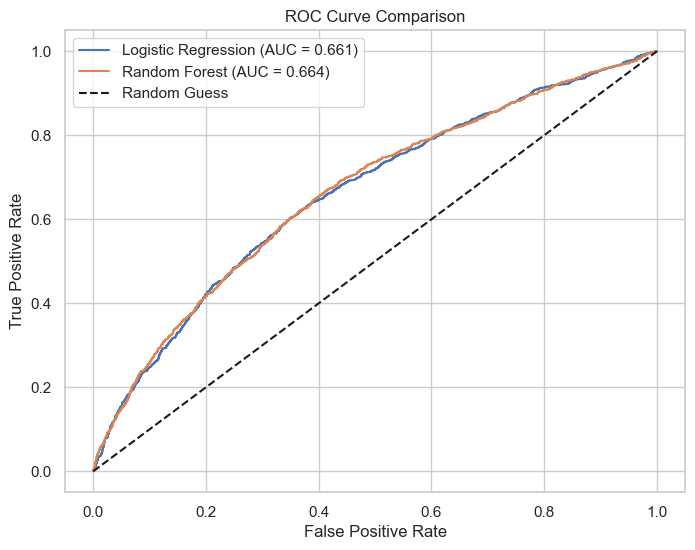

In [74]:
plt.figure(figsize=(8, 6))

for name, proba in [('Logistic Regression', y_proba_log), 
                     ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

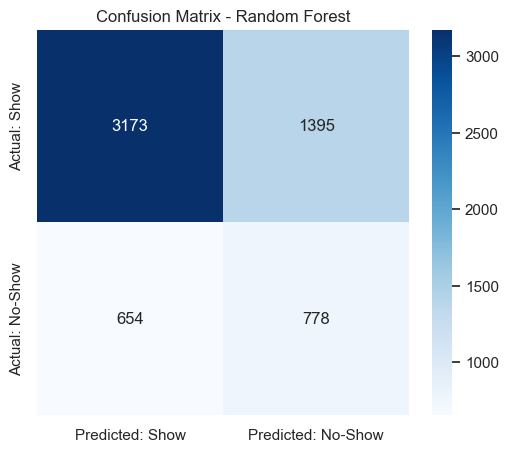

In [75]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Show', 'Predicted: No-Show'],
            yticklabels=['Actual: Show', 'Actual: No-Show'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

                         feature  importance
6         previous_noshows_count    0.171201
7                            age    0.105680
12                lead_time_days    0.062992
0              sms_reminder_sent    0.055585
4               appointment_cost    0.044669
2          distance_to_clinic_km    0.044161
1                  temperature_c    0.043341
5    previous_appointments_count    0.031706
8               has_hypertension    0.029352
9                   has_diabetes    0.020098
66       weather_condition_Rainy    0.012796
100   appointment_weekday_Monday    0.010478
11              disability_level    0.010002
95            income_bracket_Low    0.008898
68       weather_condition_Sunny    0.007471


C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\3626820225.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances.head(15), palette='mako')


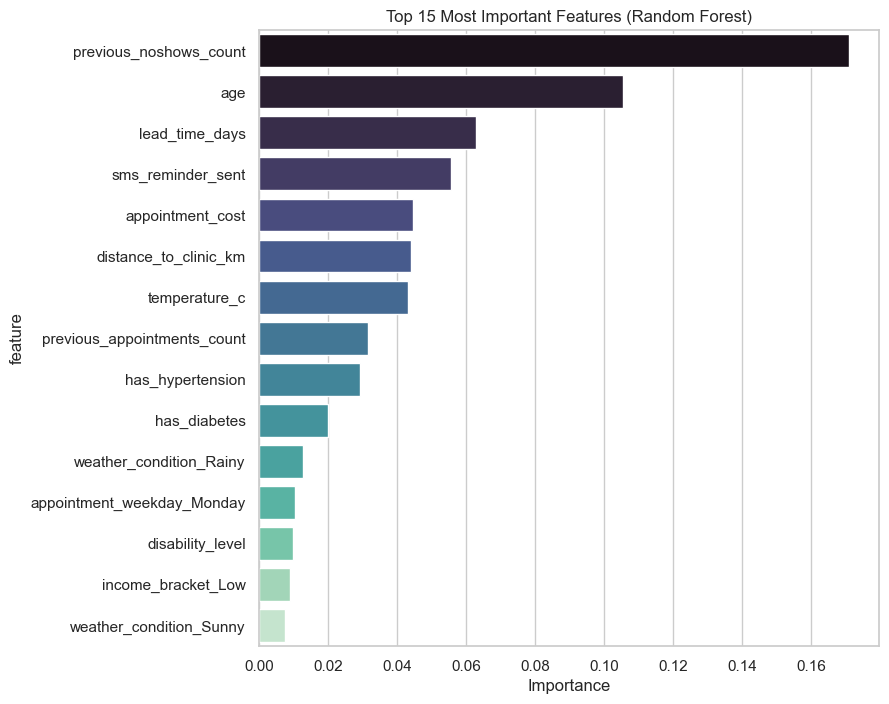

In [76]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

plt.figure(figsize=(8, 8))
sns.barplot(x='importance', y='feature', data=importances.head(15), palette='mako')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.show()

**Insight (Feature importance):** `previous_noshows_count` is by far the single
most important feature (importance ≈ 0.17), followed by `age` (≈ 0.11) and
`lead_time_days` (≈ 0.06). This matches every pattern already found in the SQL
and EDA phases: a patient's own history is the strongest signal, and lead time
is consistently important. `sms_reminder_sent`, `distance_to_clinic_km`, and
`appointment_cost` all rank in the top 8, confirming the model is learning
genuine, explainable relationships rather than noise.

In [77]:
import joblib

joblib.dump(rf_model, 'data/best_model.pkl')
joblib.dump(calibrated_model, 'data/calibrated_model.pkl')
print("Models save ho gaye!")

X_test['predicted_noshow_proba'] = y_proba_calibrated
X_test['actual_no_show'] = y_test.values
X_test.to_csv('data/test_predictions.csv', index=False)

Models save ho gaye!


C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\1150603811.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['predicted_noshow_proba'] = y_proba_calibrated
C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\1150603811.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['actual_no_show'] = y_test.values


### Overbooking Simulator

In [78]:
test_df = pd.read_csv('data/test_predictions.csv')

print(test_df[['predicted_noshow_proba', 'actual_no_show']].head())
print("Total test appointments:", len(test_df))

   predicted_noshow_proba  actual_no_show
0                0.185230               0
1                0.198642               1
2                0.501052               1
3                0.313608               0
4                0.129673               0
Total test appointments: 6000


In [79]:
CLINIC_CAPACITY = 20         
REVENUE_PER_PATIENT = test_df['appointment_cost'].median()  
COST_PER_OVERFLOW = REVENUE_PER_PATIENT * 1.5  
print(f"Revenue per patient seen: {REVENUE_PER_PATIENT:.0f}")
print(f"Cost per overflow/overcrowding incident: {COST_PER_OVERFLOW:.0f}")

test_df = test_df.sample(frac=1, random_state=1).reset_index(drop=True)

waitlist_pool = test_df.sample(frac=1, random_state=99).reset_index(drop=True)

Revenue per patient seen: 2071
Cost per overflow/overcrowding incident: 3106


In [80]:
def simulate_policy(df, pool, capacity, policy='none', fixed_overbook_pct=0.2):
    """
    policy: 'none' -> no overbooking, just book the patients in the df
            'fixed' -> always book a fixed % extra patients
            'smart' -> use the model's predicted no-show probability to determine how many extra patients to book
    """
    n_days = len(df) // capacity
    results = []

    for day in range(n_days):
        day_patients = df.iloc[day*capacity : (day+1)*capacity]

        if policy == 'none':
            booked = day_patients

        elif policy == 'fixed':
            n_extra = int(round(capacity * fixed_overbook_pct))
            extra = pool.sample(n=n_extra, random_state=day)
            booked = pd.concat([day_patients, extra])

        elif policy == 'smart':
            expected_noshows = day_patients['predicted_noshow_proba'].sum()
            n_extra = int(round(expected_noshows))
            if n_extra > 0:
                extra = pool.sample(n=n_extra, random_state=day)
                booked = pd.concat([day_patients, extra])
            else:
                booked = day_patients

        shows = (booked['actual_no_show'] == 0).sum()

        seen = min(shows, capacity)                
        overflow = max(0, shows - capacity)         
        empty_slots = max(0, capacity - shows)     

        revenue = seen * REVENUE_PER_PATIENT
        overflow_cost = overflow * COST_PER_OVERFLOW
        net_revenue = revenue - overflow_cost

        results.append({
            'day': day,
            'booked': len(booked),
            'shows': shows,
            'seen': seen,
            'overflow': overflow,
            'empty_slots': empty_slots,
            'utilization_pct': seen / capacity * 100,
            'overcrowded': int(overflow > 0),
            'revenue': revenue,
            'overflow_cost': overflow_cost,
            'net_revenue': net_revenue
        })

    return pd.DataFrame(results)

In [81]:
results_none  = simulate_policy(test_df, waitlist_pool, CLINIC_CAPACITY, policy='none')
results_fixed = simulate_policy(test_df, waitlist_pool, CLINIC_CAPACITY, policy='fixed', fixed_overbook_pct=0.2)
results_smart = simulate_policy(test_df, waitlist_pool, CLINIC_CAPACITY, policy='smart')

print("Simulated days:", len(results_none))

Simulated days: 300


**Insight:** The 6,000-row test set is split into 300 simulated "clinic days" of
20 appointments each. All three overbooking policies (No Overbooking, Fixed 20%,
Smart/Model-based) are run over the exact same 300 days, which makes the
comparison in the next step a fair, apples-to-apples test.

In [82]:
def summarize(results, name):
    return {
        'Policy': name,
        'Avg Utilization %': results['utilization_pct'].mean().round(2),
        'Total Overcrowded Days': results['overcrowded'].sum(),
        'Overcrowded Days %': (results['overcrowded'].mean() * 100).round(2),
        'Avg Empty Slots/Day': results['empty_slots'].mean().round(2),
        'Total Net Revenue': results['net_revenue'].sum().round(0)
    }

summary = pd.DataFrame([
    summarize(results_none, 'No Overbooking'),
    summarize(results_fixed, 'Fixed Overbooking (20%)'),
    summarize(results_smart, 'Smart Overbooking (Model-based)')
])

print(summary)

                            Policy  Avg Utilization %  Total Overcrowded Days  \
0                   No Overbooking              76.13                       0   
1          Fixed Overbooking (20%)              90.47                      44   
2  Smart Overbooking (Model-based)              92.68                      71   

   Overcrowded Days %  Avg Empty Slots/Day  Total Net Revenue  
0                0.00                 4.77          9460328.0  
1               14.67                 1.91         11045678.0  
2               23.67                 1.46         11168903.0  


**Insight (Headline result of the whole project):** "No Overbooking" leaves the
clinic under-utilized (76.13%, 0% overcrowding). "Fixed 20% Overbooking" raises
utilization to 90.47% but introduces overcrowding on 14.67% of days. The
**Smart, model-based policy achieves the highest utilization (92.68%) and the
highest total net revenue (Rs. 1,11,68,903)** of all three policies — slightly
ahead of Fixed Overbooking (Rs. 1,10,45,678) — even though it also accepts
somewhat more overcrowding (23.67% of days) in exchange. This is the project's
core finding: using calibrated no-show probabilities to make a per-day
overbooking decision produces a better financial outcome than either not
overbooking at all or overbooking by a blind fixed percentage.

C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\626561052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Avg Utilization %', data=summary, palette='Blues_d')


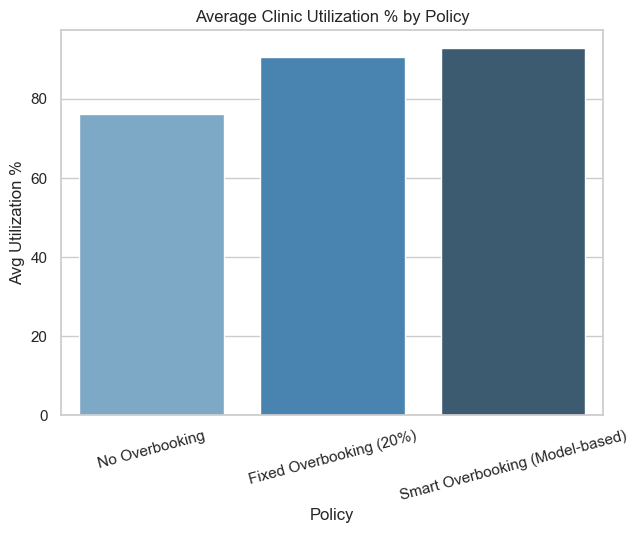

In [83]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Policy', y='Avg Utilization %', data=summary, palette='Blues_d')
plt.title('Average Clinic Utilization % by Policy')
plt.xticks(rotation=15)
plt.show()

C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\3854272286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Overcrowded Days %', data=summary, palette='Reds')


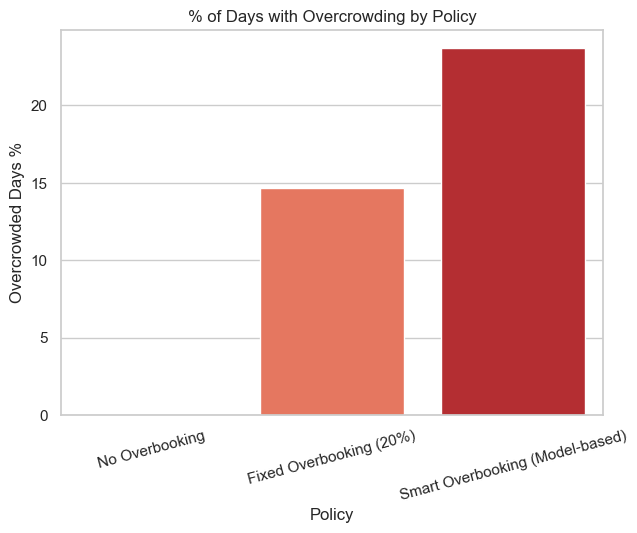

In [84]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Policy', y='Overcrowded Days %', data=summary, palette='Reds')
plt.title('% of Days with Overcrowding by Policy')
plt.xticks(rotation=15)
plt.show()

C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\3083238639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Total Net Revenue', data=summary, palette='Greens_d')


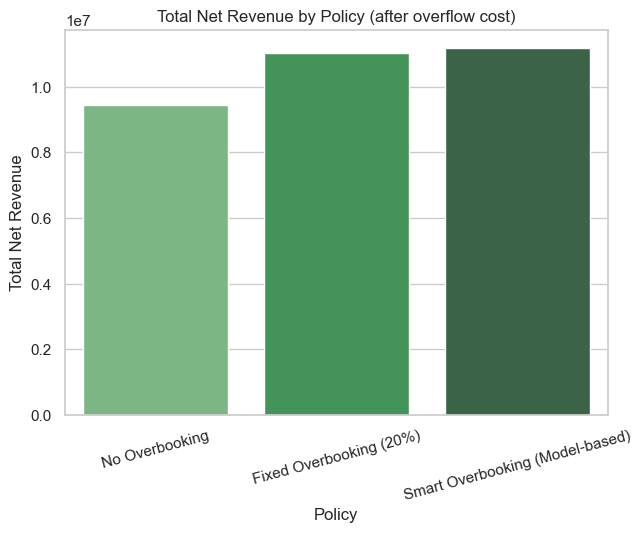

In [85]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Policy', y='Total Net Revenue', data=summary, palette='Greens_d')
plt.title('Total Net Revenue by Policy (after overflow cost)')
plt.xticks(rotation=15)
plt.show()

C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\4118714471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Avg Utilization %', data=summary, ax=axes[0], palette='Blues_d')
C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\4118714471.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Overcrowded Days %', data=summary, ax=axes[1], palette='Reds')
C:\Users\Bizone\AppData\Local\Temp\ipykernel_20928\4118714471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Total Net Revenue', data=summar

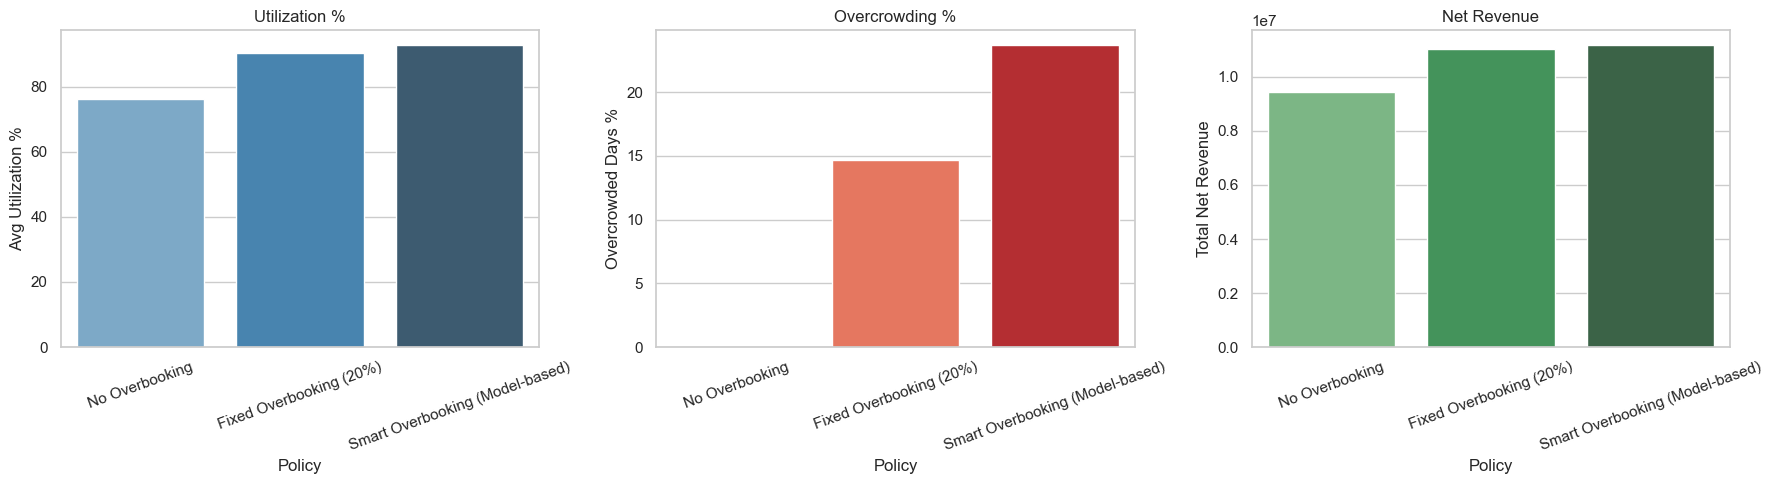

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Policy', y='Avg Utilization %', data=summary, ax=axes[0], palette='Blues_d')
axes[0].set_title('Utilization %')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x='Policy', y='Overcrowded Days %', data=summary, ax=axes[1], palette='Reds')
axes[1].set_title('Overcrowding %')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(x='Policy', y='Total Net Revenue', data=summary, ax=axes[2], palette='Greens_d')
axes[2].set_title('Net Revenue')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('data/policy_comparison.png', dpi=150)
plt.show()

In [87]:
summary.to_csv('data/policy_comparison_summary.csv', index=False)
results_smart.to_csv('data/smart_policy_daily_results.csv', index=False)

print("Simulation results saved!")

Simulation results saved!
